# 04 · Optimization — the engines under the models

Both regressions in `dolcestat` are fit by the same family of **optimizers**:
algorithms that start from some weights and iteratively reduce a loss. You met
them through the model wrappers in notebooks 02–03; here we drive them directly
to understand how they behave — and *when the choice of optimizer matters most*.

The short answer: it matters on **ill-conditioned** problems, where the loss
surface is a long, narrow valley. That's exactly where momentum and Newton's
method earn their keep, so we'll build such a problem on purpose.

## An ill-conditioned problem

The difficulty of an optimization problem is captured by the **condition
number** κ of the loss curvature (the Hessian, which for least squares is
proportional to XᵀX). When κ is large the loss is a stretched valley: steep
across the narrow direction, nearly flat along the long one.

An easy way to create this is to leave features on **very different scales** —
here one feature is ~12× larger than the other. (This is precisely the situation
the scaling in [`01_preprocessing`](01_preprocessing.ipynb) exists to prevent,
as we'll confirm at the end.)

In [1]:
import numpy as np
import polars as pl

from dolcestat.preprocessing import DolceSet
from dolcestat.core import (
    LU,
    BatchSampler,
    MeanSquaredError,
    MiniBatchSampler,
    Trainer,
    ZeroParametersInitializer,
)
from dolcestat.neural_networks.layers import DenseLayer
from dolcestat.neural_networks.networks import Sequential
from dolcestat.optimization.gradient_descent import GradientDescent
from dolcestat.optimization.analyzer import OptimizerAnalyzer
from dolcestat.linear_models import LinearRegression

rng = np.random.default_rng(0)
n = 200
x1 = rng.normal(0, 1, n)          # feature on a small scale
x2 = rng.normal(0, 1, n) * 12     # feature on a ~12x larger scale
y = 1.5 * x1 + 0.1 * x2 + 0.5 + rng.normal(0, 0.3, n)

df = pl.DataFrame({"x1": x1, "x2": x2, "y": y})
data = DolceSet()
data.load_from_polars_dataframe(df, target_col="y")

X_bias = np.column_stack((data.X, np.ones(n)))
kappa = np.linalg.cond(X_bias.T @ X_bias)
print(f"condition number of XᵀX ≈ {kappa:,.0f}   (large ⇒ ill-conditioned)")


def linear_model():
    """A freshly initialized linear model: one layer, identity activation.

    Least squares *is* a one-layer network, so we can point the optimizers at
    the same object the regressions use. Each call starts again from zero, so
    every run below begins from identical weights.
    """
    return Sequential(
        DenseLayer(LU(), data.X.shape[1], 1, ZeroParametersInitializer())
    )

condition number of XᵀX ≈ 166   (large ⇒ ill-conditioned)


## Plain gradient descent

Gradient descent can only take a step up to a maximum stable size, and that
ceiling *shrinks* as κ grows — so on an ill-conditioned problem we're forced into
a small learning rate. Worse, the number of steps to converge grows roughly
**linearly in κ**: plain GD zig-zags slowly down the valley.

plain gradient descent: 1326 steps


<Axes: title={'center': 'Loss'}, xlabel='Epoch', ylabel='Loss'>

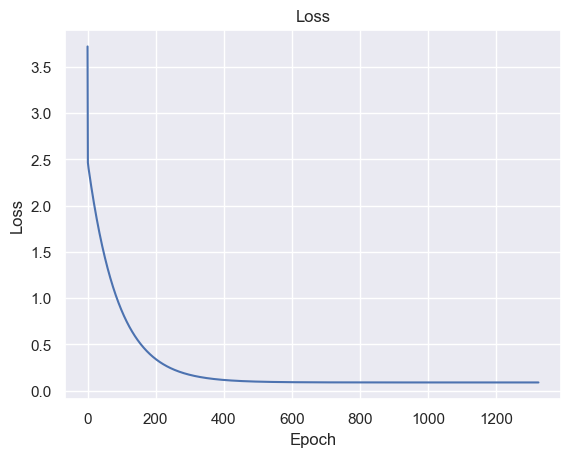

In [2]:
plain = Trainer(
    model=linear_model(),
    loss=MeanSquaredError(),
    optimizer=GradientDescent(alpha=0.003),
    sampler=BatchSampler(),
)
plain_history = plain.run(data, n_epochs=20000, tol=1e-8)

print("plain gradient descent:", plain_history.n_steps, "steps")
OptimizerAnalyzer(plain_history).plot_loss()

## Momentum: Polyak and Nesterov

Momentum carries a fraction of the previous step into the next, damping the
zig-zag and letting the optimizer build speed along the valley floor. The
optimizer keeps one **velocity buffer** per parameter — it is the optimizer's
only state — and `momentum_type` chooses what to do with it:

- **`"polyak"`** (heavy ball) — accumulate `v = βv + g`, then step along `v`.
- **`"nesterov"`** — look ahead to where momentum is carrying you, then correct.

Both cut the iteration count from ~linear in κ toward ~**√κ** — a big win here.
(The trade-off: momentum tolerates a smaller maximum step, so at very aggressive
learning rates it can overshoot.)

> **A note on this Nesterov.** The textbook derivation evaluates the gradient at
> the *look-ahead* point — it shifts the weights **before** the backward pass.
> An optimizer that runs *after* backpropagation structurally cannot do that:
> by then `grad` already describes the unshifted weights. `dolcestat` therefore
> implements the **correction form** (the same one PyTorch uses), `update =
> g + βv`, which reaches the same place by a slightly different path. The two
> agree asymptotically; they are not step-for-step identical.

plain   : 1326 steps
polyak  : 162 steps
nesterov: 156 steps


<Axes: title={'center': 'Loss comparison'}, xlabel='Epoch', ylabel='Loss'>

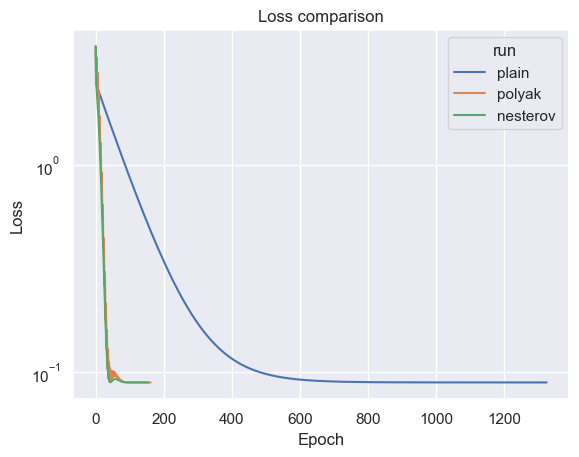

In [3]:
def run_gd(momentum_type=None, alpha=0.003, sampler=None, dataset=None, **kwargs):
    """Train a fresh linear model and hand back the History."""
    trainer = Trainer(
        model=linear_model(),
        loss=MeanSquaredError(),
        optimizer=GradientDescent(alpha=alpha, momentum_type=momentum_type,
                                  momentum_rate=0.9),
        sampler=sampler if sampler is not None else BatchSampler(),
    )
    return trainer.run(dataset if dataset is not None else data, **kwargs)


polyak_history = run_gd("polyak", n_epochs=20000, tol=1e-8)
nesterov_history = run_gd("nesterov", n_epochs=20000, tol=1e-8)

print("plain   :", plain_history.n_steps, "steps")
print("polyak  :", polyak_history.n_steps, "steps")
print("nesterov:", nesterov_history.n_steps, "steps")

OptimizerAnalyzer([plain_history, polyak_history, nesterov_history],
                  labels=["plain", "polyak", "nesterov"]).plot_loss(log_scale=True)

## Newton's method

Gradient descent uses only the slope. **Newton's method** also uses the
curvature — it inverts the Hessian to rescale the step — which makes it
essentially **independent of κ**: it reaches the minimum of a quadratic loss in
a handful of iterations no matter how stretched the valley. Nesterov momentum
already cut the iteration count to ~√κ; Newton goes further still, since it
doesn't scale with κ at all. That power costs a matrix inversion per step.

**Why it isn't an `Optimizer`.** Everything above plugs into `Trainer` because
it satisfies one narrow contract: *given each parameter's gradient, update that
parameter*. Newton cannot. It needs the design matrix `X`, and it needs a single
**joint** Hessian over all the weights at once — a per-parameter list of
gradients simply does not contain either. So Newton lives where those objects
do: as a fitting strategy on the model itself, reached with
`LinearRegression("newton")`. Same parameters, same `predict`, different route
to the numbers.

For least squares the Hessian `(2/n)XᵀX` is *constant* — the loss is exactly
quadratic — so Newton lands on the normal-equation solution in one step and
spends the second only confirming the loss stopped moving.

nesterov: 156 steps   |   Newton: 3 iterations
Newton weights     : [1.520131 0.101488] [0.502803]
closed-form weights: [1.520131 0.101488] [0.502803]


<Axes: title={'center': 'Loss comparison'}, xlabel='Epoch', ylabel='Loss'>

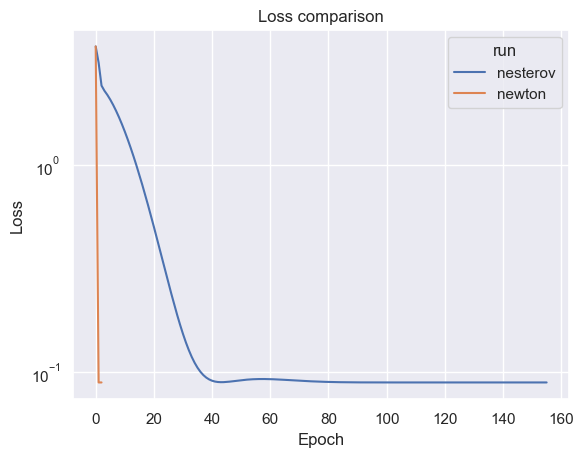

In [4]:
newton_model = LinearRegression("newton").fit(data)
closed_form = LinearRegression("closed form").fit(data)

print("nesterov:", nesterov_history.n_steps, "steps   |   Newton:",
      newton_model.history.n_epochs, "iterations")
print("Newton weights     :", np.round(newton_model.weights.ravel(), 6),
      np.round(newton_model.bias, 6))
print("closed-form weights:", np.round(closed_form.weights.ravel(), 6),
      np.round(closed_form.bias, 6))

OptimizerAnalyzer([nesterov_history, newton_model.history],
                  labels=["nesterov", "newton"]).plot_loss(log_scale=True)

## The cheap fix: scaling

You usually don't need heavy machinery to beat ill-conditioning — you can just
remove it. **Standardizing** the features (notebook 01) puts them on a common
scale, which collapses κ back toward 1. Watch plain gradient descent go from
thousands of iterations to a handful:

In [5]:
scaled = DolceSet()
scaled.load_from_polars_dataframe(df, target_col="y")
scaled.scale("standardize")          # put both features on a common scale

Xb = np.column_stack((scaled.X, np.ones(n)))
print(f"condition number after scaling ≈ {np.linalg.cond(Xb.T @ Xb):,.1f}")

well_conditioned = run_gd(alpha=0.4, dataset=scaled, n_epochs=20000, tol=1e-8)
print("plain gradient descent on scaled data:", well_conditioned.n_steps, "steps")

condition number after scaling ≈ 1.1
plain gradient descent on scaled data: 10 steps


## A different axis: how much data per step

Conditioning aside, how many rows each step uses is a trade-off between step
cost and step noise. That choice belongs to a **`Sampler`**, an object separate
from the optimizer — the optimizer only knows how to turn a gradient into an
update, and never learns how the batch was chosen (shown here on the
well-conditioned, scaled data):

- **`BatchSampler()`** — the whole dataset every step: smooth but heavier.
- **`MiniBatchSampler(batch_size=40)`** — a random 40 rows: a middle ground.
- **`MiniBatchSampler(batch_size=1)`** — a single random row: cheap, noisy steps.

Two units matter now. A **step** is one weight update; an **epoch** is one pass
of the sampler. With `BatchSampler` they are the same thing, which is why the
counts above read as "steps". `History` records the batch loss every step and
the full-dataset loss every epoch — convergence is judged on the latter, since a
tolerance applied to noisy per-batch losses would fire on the noise.

Passing several `History` objects to one `OptimizerAnalyzer` overlays their
curves.

batch        12 epochs /  12 steps
mini_batch  345 epochs / 345 steps
sgd         500 epochs / 500 steps


<Axes: title={'center': 'Loss comparison'}, xlabel='Epoch', ylabel='Loss'>

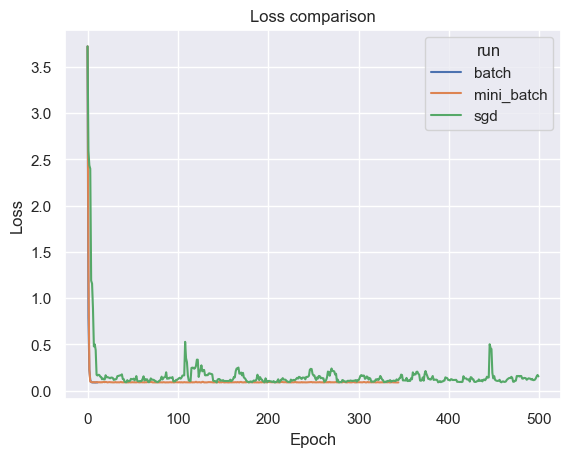

In [6]:
np.random.seed(0)   # the mini-batch samplers draw rows at random

samplers = {
    "batch": (BatchSampler(), 0.3),
    "mini_batch": (MiniBatchSampler(batch_size=40), 0.3),
    "sgd": (MiniBatchSampler(batch_size=1), 0.1),
}

runs = {
    label: run_gd(alpha=alpha, sampler=sampler, dataset=scaled, n_epochs=500)
    for label, (sampler, alpha) in samplers.items()
}

for label, history in runs.items():
    print(f"{label:11s} {history.n_epochs:3d} epochs / {history.n_steps:3d} steps")

OptimizerAnalyzer(list(runs.values()), labels=list(runs)).plot_loss()

## Recap

Optimizer choice matters most when the problem is ill-conditioned: momentum buys
you roughly √κ over κ iterations, and Newton's use of the Hessian makes it
condition-invariant — while a quick standardize often removes the problem
altogether. These are the very engines the model wrappers run for you (pass a
configured one via `optimizer=`; see notebooks 02–03).

Next, a model with no optimizer at all: [`05_knn`](05_knn.ipynb).